In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [3]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [4]:
import os

print(os.listdir("dataset"))

['Positive', 'Negative']


In [5]:
dataset_path = "dataset/archive"

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [7]:
import os
os.listdir()

['.config', 'dataset', 'archive.zip', 'sample_data']

In [8]:
import os
os.listdir("dataset")

['Positive', 'Negative']

In [ ]:
dataset_path = "dataset"

In [9]:
image_size = (128, 128)
batch_size = 16

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

Found 40000 files belonging to 2 classes.
Using 32000 files for training.
Found 40000 files belonging to 2 classes.
Using 8000 files for validation.


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [11]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [12]:
# Step 1: Load MobileNetV2 (a pretrained AI model from Google)
base_model = keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze it - we don't retrain Google's work

# Step 2: Build our crack detection model ON TOP of MobileNetV2
inputs = keras.Input(shape=(128, 128, 3))
x = data_augmentation(inputs)                          # Apply augmentation
x = keras.applications.mobilenet_v2.preprocess_input(x)  # Normalize for MobileNet
x = base_model(x, training=False)                     # Pass through MobileNet
x = layers.GlobalAveragePooling2D()(x)                # Compress features
x = layers.Dropout(0.2)(x)                            # Prevent overfitting
outputs = layers.Dense(1, activation='sigmoid')(x)    # Final answer: crack or not

model = keras.Model(inputs, outputs)

model.summary()  # Show model structure

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
callbacks = [
    # Stop training if accuracy stops improving for 5 epochs in a row
    keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True,
        monitor='val_accuracy'
    ),

    # Reduce learning rate if stuck (like slowing down to find the right path)
    keras.callbacks.ReduceLROnPlateau(
        factor=0.5,
        patience=3,
        monitor='val_loss'
    ),

    # Save your best model automatically so you don't lose progress
    keras.callbacks.ModelCheckpoint(
        "best_crack_model.h5",
        save_best_only=True,
        monitor='val_accuracy'
    )
]

In [15]:
print("Starting training... this may take a while on CPU ☕")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

print("Training complete! ✅")

Starting training... this may take a while on CPU ☕
Epoch 1/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9883 - loss: 0.0373

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 360s 175ms/step - accuracy: 0.9955 - loss: 0.0149 - val_accuracy: 0.9983 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 2/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.9971 - loss: 0.0097

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 307s 153ms/step - accuracy: 0.9977 - loss: 0.0070 - val_accuracy: 0.9985 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 3/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 306s 153ms/step - accuracy: 0.9981 - loss: 0.0055 - val_accuracy: 0.9974 - val_loss: 0.0098 - learning_rate: 0.0010
Epoch 4/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 321s 153ms/step - accuracy: 0.9980 - loss: 0.0063 - val_accuracy: 0.9980 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 5/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 306s 153ms/step - accuracy: 0.9982 - loss: 0.0054 - val_accuracy: 0.9981 - val_loss: 0.0062 - learning_rate: 0.0010
Epoch 6/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 322s 153ms/step - accuracy: 0.9981 - loss: 0.0060 - val_accuracy: 0.9984 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 7/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9982 - loss: 0.0056

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 304s 152ms/step - accuracy: 0.9982 - loss: 0.0057 - val_accuracy: 0.9986 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 8/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 305s 152ms/step - accuracy: 0.9986 - loss: 0.0052 - val_accuracy: 0.9980 - val_loss: 0.0077 - learning_rate: 0.0010
Epoch 9/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 305s 152ms/step - accuracy: 0.9988 - loss: 0.0046 - val_accuracy: 0.9984 - val_loss: 0.0063 - learning_rate: 0.0010
Epoch 10/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 306s 153ms/step - accuracy: 0.9986 - loss: 0.0048 - val_accuracy: 0.9981 - val_loss: 0.0057 - learning_rate: 0.0010
Epoch 11/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 357s 170ms/step - accuracy: 0.9986 - loss: 0.0041 - val_accuracy: 0.9984 - val_loss: 0.0061 - learning_rate: 5.0000e-04
Epoch 12/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 305s 152ms/step - accuracy: 0.9988 - loss: 0.0047 - val_accuracy: 0.9984 - val_loss: 0.0060 - learning_rate: 5.0000e-04
Training complete! ✅


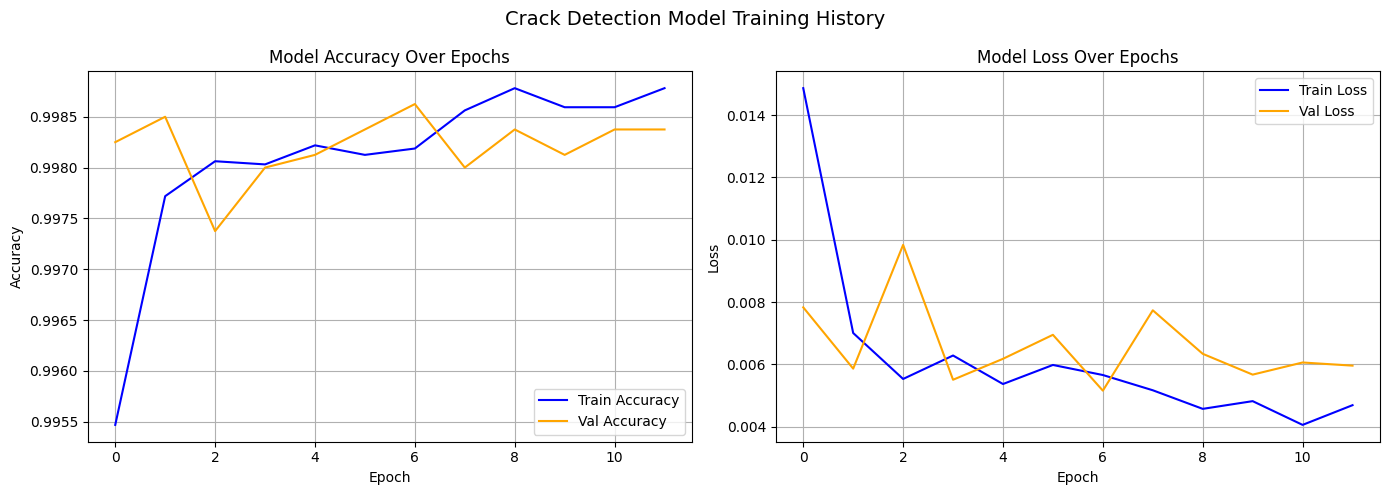

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy graph
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax1.set_title('Model Accuracy Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss graph
ax2.plot(history.history['loss'], label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax2.set_title('Model Loss Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Crack Detection Model Training History', fontsize=14)
plt.tight_layout()
plt.show()

Generating predictions on validation data...
500/500 ━━━━━━━━━━━━━━━━━━━━ 51s 98ms/step


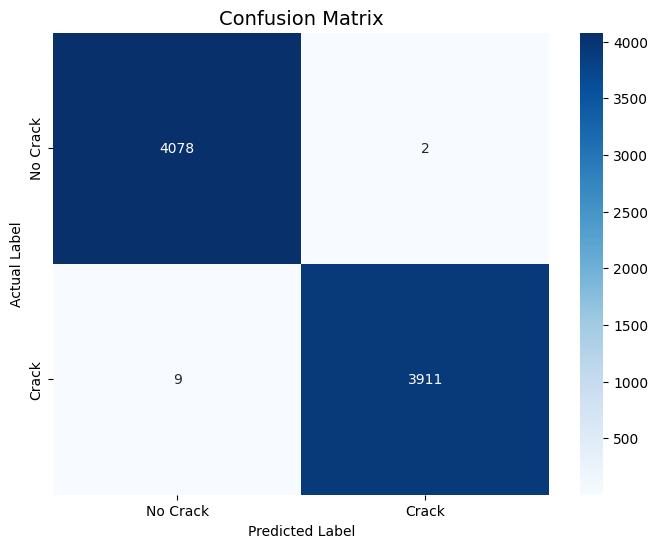


--- Classification Report ---
              precision    recall  f1-score   support

    No Crack       1.00      1.00      1.00      4080
       Crack       1.00      1.00      1.00      3920

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



In [17]:
print("Generating predictions on validation data...")

# Get all true labels and predictions
y_true = np.concatenate([y.numpy() for x, y in val_ds], axis=0)
y_pred_prob = model.predict(val_ds)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Crack', 'Crack'],
            yticklabels=['No Crack', 'Crack'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Full Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred,
      target_names=['No Crack', 'Crack']))

In [18]:
def predict_crack(img_path):
    """Give it any image path and it will predict if there's a crack"""
    from PIL import Image

    # Load and prepare the image
    img = Image.open(img_path).resize((128, 128))
    img_array = np.array(img)
    img_array_expanded = np.expand_dims(img_array, axis=0)

    # Make prediction
    prediction = model.predict(img_array_expanded)[0][0]

    # Show result
    if prediction > 0.5:
        label = "⚠️ CRACK DETECTED"
        color = 'red'
        confidence = prediction
    else:
        label = "✅ NO CRACK"
        color = 'green'
        confidence = 1 - prediction

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"{label}\nConfidence: {confidence:.1%}",
              color=color, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

# To use this function, call it like this:
# predict_crack("path/to/your/image.jpg")
print("predict_crack() function is ready! ✅")
print("Usage: predict_crack('your_image.jpg')")

predict_crack() function is ready! ✅
Usage: predict_crack('your_image.jpg')


In [19]:
model.save("crack_detection_final.h5")
print("Model saved as 'crack_detection_final.h5' ✅")
print("Download it from the Files panel on the left sidebar in Colab")

Model saved as 'crack_detection_final.h5' ✅
Download it from the Files panel on the left sidebar in Colab
